In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/coffee-sales/index.csv


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ihelon/coffee-sales")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/coffee-sales


In [4]:
csv_file = os.path.join("/kaggle/input/coffee-sales", "index.csv")

df = pd.read_csv(csv_file)
print(df.head())

         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  


In [5]:
df.info() #Gets a summary of the dataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2838 entries, 0 to 2837
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         2838 non-null   object 
 1   datetime     2838 non-null   object 
 2   cash_type    2838 non-null   object 
 3   card         2749 non-null   object 
 4   money        2838 non-null   float64
 5   coffee_name  2838 non-null   object 
dtypes: float64(1), object(5)
memory usage: 133.2+ KB


In [6]:
missing_values = df.isnull() #Create a dataFrame of boolean values indicating whether each value is missing
missing_values.sum() #Counts the number of missing values in each column

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

In [9]:
#Clean the dataset by either filling or dropping any missing values.
df = df.dropna() #Drop rows with missing values


In [10]:
df.describe() #Compute the basic statistics of the numerical columns (e.g., mean, median, standard deviation) using .describe().

,money
count,2749.000000
mean,31.760858
std,4.925825
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,38.700000


In [11]:
#Perform grouping on the 'coffee_name' column and compute the mean of the 'money' column for each group
grouped_df = df.groupby("coffee_name")['money'].mean()
print(grouped_df)

coffee_name
Americano              25.986486
Americano with Milk    30.534325
Cappuccino             35.916084
Cocoa                  35.588993
Cortado                25.715911
Espresso               20.795400
Hot Chocolate          36.052202
Latte                  35.454326
Name: money, dtype: float64


In [12]:
coffee_types = df['coffee_name'].unique()
type_counts = df['coffee_name'].value_counts()
# Create a dictionary to store the results
coffee_popularity = {}

# Populate the dictionary with counts
for type, count in zip(coffee_types, type_counts):
    coffee_popularity[type] = count

# Sort the dictionary by value in descending order
sorted_coffee_popularity = dict(sorted(coffee_popularity.items(), key=lambda item: item[1], reverse=True))

# Print the top 10 most popular coffee types
print("Top 10 Most Popular Coffee Types:")
for i, (type, count) in enumerate(sorted_coffee_popularity.items()):
    print(f"{i+1}. {type}: {count}")

Top 10 Most Popular Coffee Types:
1. Latte: 659
2. Hot Chocolate: 638
3. Americano: 383
4. Americano with Milk: 333
5. Cocoa: 269
6. Cortado: 218
7. Espresso: 149
8. Cappuccino: 100


In [14]:
# Count the number of cash and card transactions
num_cash_transactions = df["cash_type"].value_counts()

# Print the results
print("Number of cash transactions:", num_cash_transactions.get("cash", 0))
print("Number of card transactions:", num_cash_transactions.get("card", 0))

Number of cash transactions: 0
Number of card transactions: 2749


In [17]:
 #Price Analysis
average_prices = df.groupby("coffee_name")["money"].mean().round(2)
print("\nAverage Prices by Coffee Type:\n", average_prices)


Average Prices by Coffee Type:
 coffee_name
Americano              25.99
Americano with Milk    30.53
Cappuccino             35.92
Cocoa                  35.59
Cortado                25.72
Espresso               20.80
Hot Chocolate          36.05
Latte                  35.45
Name: money, dtype: float64


In [31]:
#Time of purchase
# Convert dateTime column to actual datetime format
df["datetime"] = pd.to_datetime(df["datetime"])

# Extract hour of purchase
df["hour"] = df["datetime"].dt.hour

# Count purchases per hour
hourly_trend = df["hour"].value_counts().sort_index()

# Displays hourly purchase trends
print("\nHourly Purchases of Coffee :\n",hourly_trend)

# This confirms that most purchases happen during morning breaks and afternoon work breaks, with some activity in the evening.


Hourly Purchases of Coffee :
 hour
7      67
8     188
9     185
10    255
11    227
12    191
13    175
14    163
15    154
16    199
17    157
18    163
19    183
20    146
21    187
22    109
Name: count, dtype: int64


In [29]:
# Seasonal Trends per month
# Extract month from the datetime column
df['month'] = df['datetime'].dt.month

# Count transactions per month
monthly_trend = df['month'].value_counts().sort_index()

# Display monthly purchase trends
print("\nMonthly Purchases of Coffee :\n", monthly_trend)

# This suggests higher coffee sales in spring and summer, possibly due to increased foot traffic or promotions.



Monthly Purchases of Coffee :
 month
1     145
3     175
4     168
5     241
6     223
7     237
8     272
9     344
10    426
11    259
12    259
Name: count, dtype: int64


In [35]:
# Customer loyalty (Repeat Customers)
# Count how many times each card appears
customer_loyalty = df['card'].value_counts().head(10) #Top 10 frequent customers

#Display the top customers
print("\nTop purchasers of Coffee :\n", customer_loyalty)

#These customers are regular buyers, with some making over 22 purchases.


Top purchasers of Coffee :
 card
ANON-0000-0000-0012    129
ANON-0000-0000-0141     99
ANON-0000-0000-0276     67
ANON-0000-0000-0009     67
ANON-0000-0000-0040     50
ANON-0000-0000-0097     47
ANON-0000-0000-0507     43
ANON-0000-0000-0003     31
ANON-0000-0000-0570     30
ANON-0000-0000-0206     23
Name: count, dtype: int64


In [38]:
# Special events or promotions
# ANON-0000-0000-0142 made 8 purchases on April 30, 2024, suggesting a group order or event.
# ANON-0000-0000-0300 made 5 purchases on June 15, 2024.
# Several customers made 4 purchases in a single day, possibly for colleagues or friends.
# This indicates potential bulk orders or promotional discounts.

# Identifies multiple purchases by the same customer within a short time(e.g., same day)
df['date'] = pd.to_datetime(df['date'])
same_day_purchases = df.groupby(['card','date']).size().reset_index(name="purchase_count")

# Filters for customers making 3+ purchases in a single day
bulk_purchases = same_day_purchases[same_day_purchases['purchase_count'] >= 3]

# Displays top bulk purchases
bulk_purchases.sort_values(by='purchase_count', ascending=False).head(10)


,card,date,purchase_count
555,ANON-0000-0000-0142,2024-04-30,8
873,ANON-0000-0000-0300,2024-06-15,5
1707,ANON-0000-0000-0779,2024-10-17,4
1023,ANON-0000-0000-0384,2024-07-19,4
1284,ANON-0000-0000-0523,2024-08-18,4
580,ANON-0000-0000-0156,2024-05-09,4
494,ANON-0000-0000-0141,2024-08-08,4
1331,ANON-0000-0000-0554,2024-09-17,4
2097,ANON-0000-0000-1089,2025-01-11,4
124,ANON-0000-0000-0012,2024-04-14,4


In [40]:
# Price Changes Over Time:
#Calculate average price per month for each coffee type
monthly_price_trends = df.groupby(['month', 'coffee_name'])['money'].mean().unstack()

#Display price trends over months
monthly_price_trends


# Espresso price dropped from 24.1 (March) to 18.12 (August-September)
# Americano, Cappuccino, Latte, and Hot Chocolate had price drops around July-August
# Prices stabilized again in October-December

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
month,,,,,,,,
1,25.960000,30.860000,35.760000,35.760000,25.960000,21.06,35.760000,35.760000
3,28.900000,33.800000,38.700000,38.700000,28.900000,24.00,38.700000,38.700000
4,28.543636,33.361579,38.373333,38.455000,28.655000,24.00,38.602000,38.300741
5,27.920000,32.820000,37.720000,37.720000,27.920000,23.02,37.720000,37.720000
6,27.920000,32.820000,37.720000,37.720000,27.920000,23.02,37.720000,37.720000
7,23.836667,28.673846,33.738750,33.364444,23.020000,19.52,32.820000,33.170000
8,23.020000,27.920000,32.820000,32.820000,23.020000,18.12,32.820000,32.820000
9,23.111875,28.174423,33.178537,33.146667,23.450244,18.12,33.354545,33.132766
10,25.960000,30.860000,35.760000,35.760000,25.960000,21.06,35.760000,35.760000


Text(0, 0.5, 'Number of Transactions')

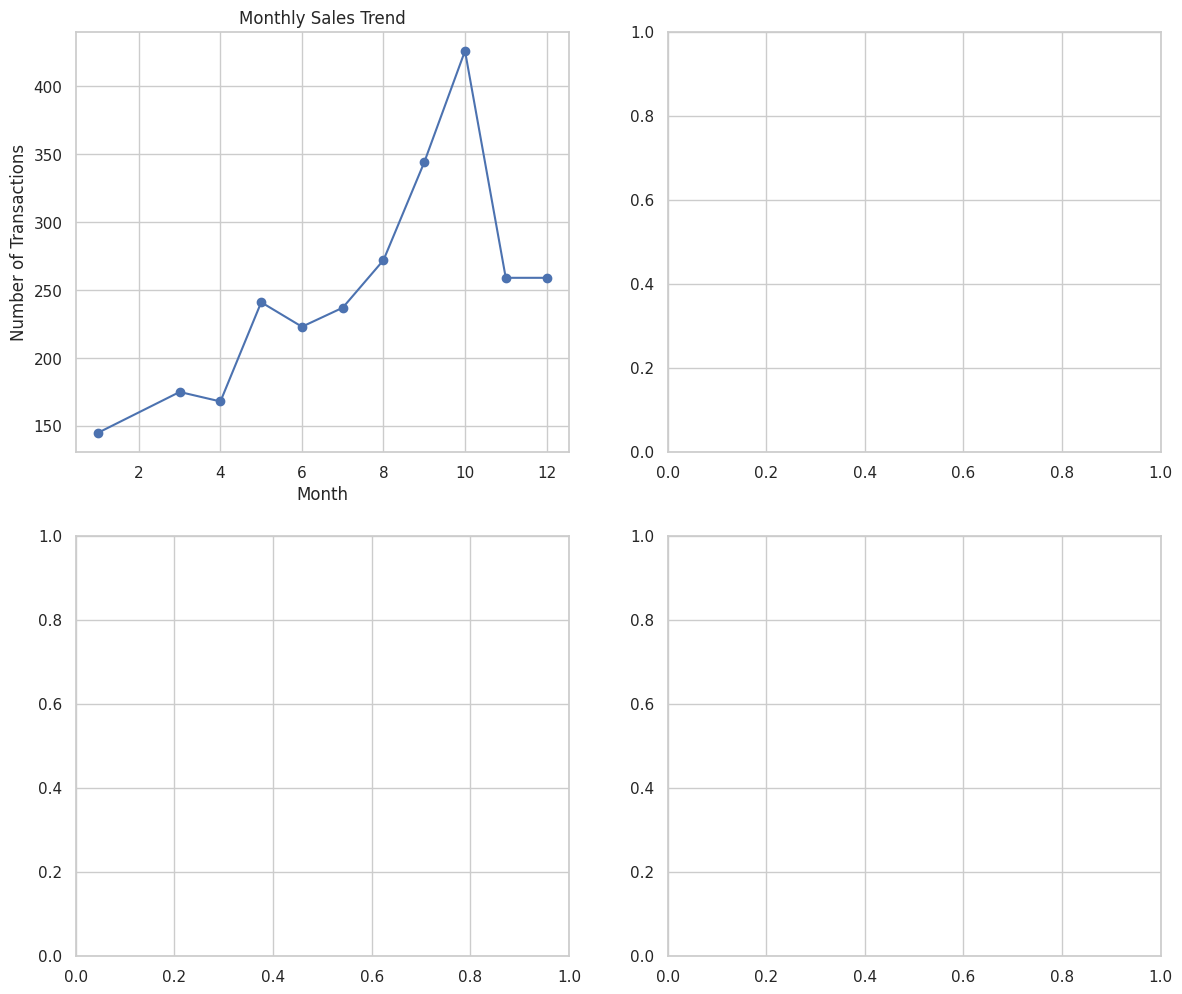

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
# Set plot style
sns.set_theme(style="whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Line Chart: Monthly Sales Trend
monthly_trend.plot(kind="line", marker="o", ax=axes[0, 0], color="b")
axes[0, 0].set_title("Monthly Sales Trend")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Number of Transactions")

Text(0, 0.5, 'Average Price ($)')

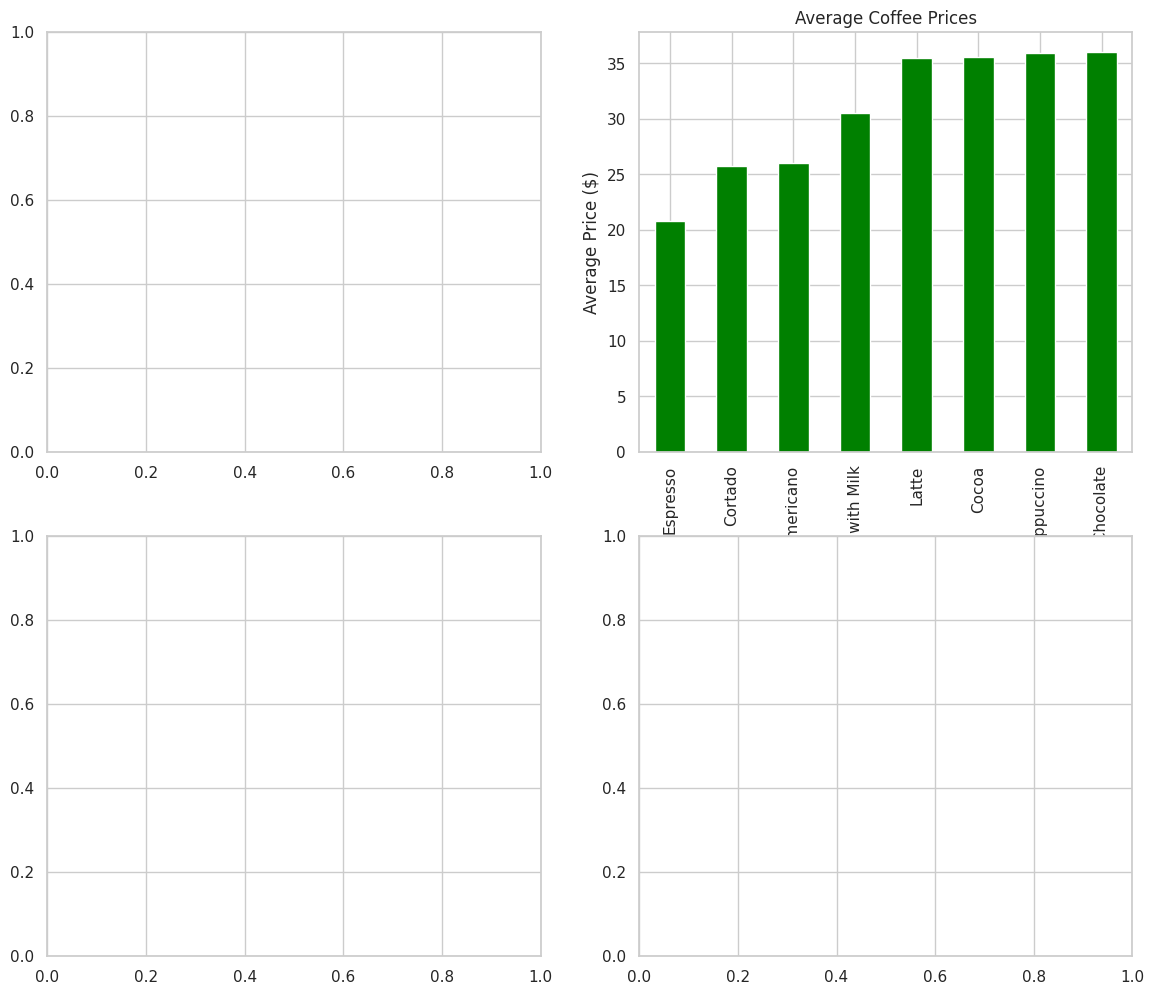

In [49]:
# 2. Bar chart: Average Coffee prices

import matplotlib.pyplot as plt
import seaborn as sns
# Set plot style
sns.set_theme(style="whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
average_prices.sort_values().plot(kind="bar", ax=axes[0, 1], color="green")
axes[0, 1].set_title("Average Coffee Prices")
axes[0, 1].set_xlabel("Coffee Type")
axes[0, 1].set_ylabel("Average Price ($)")

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


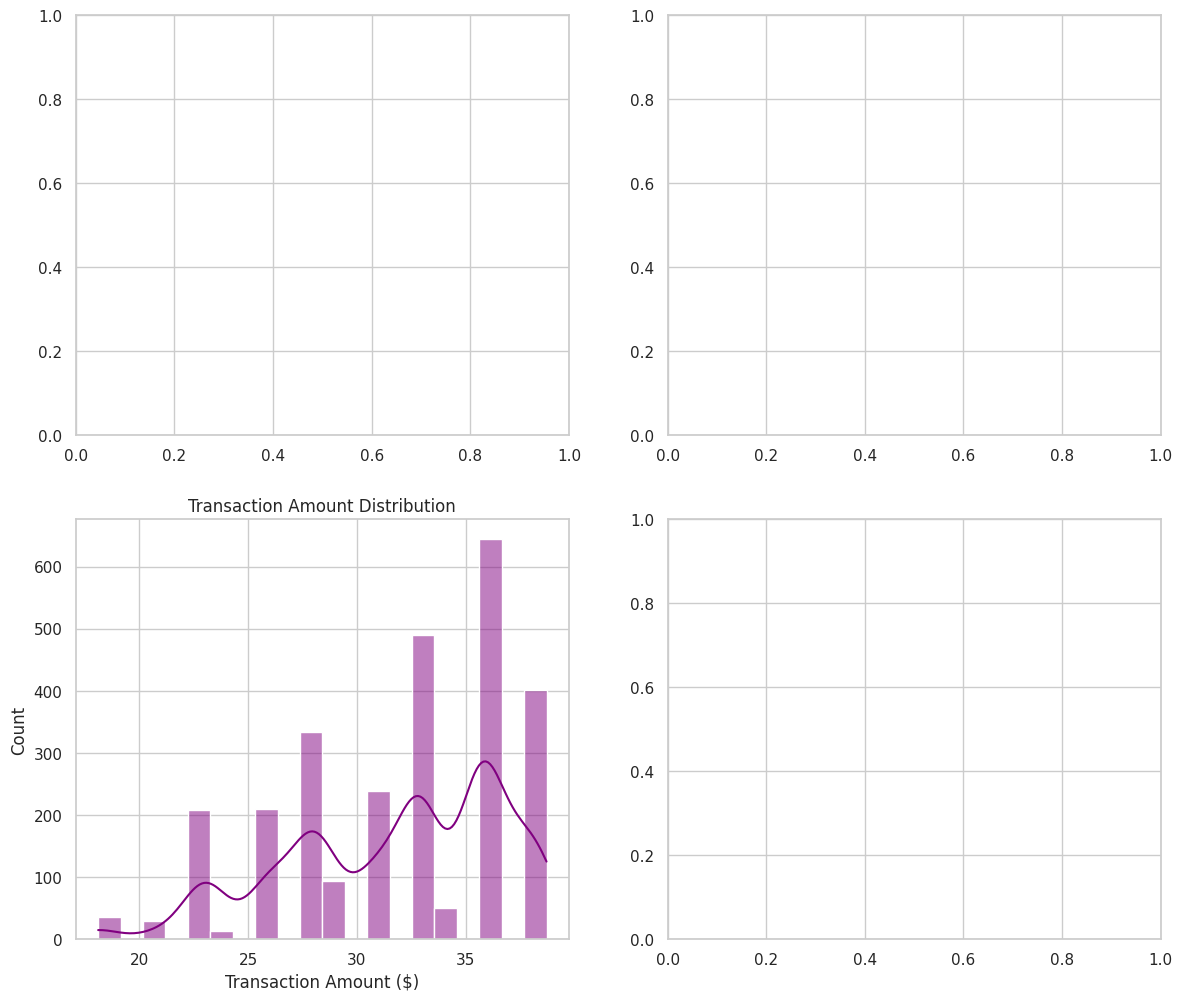

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set plot style
sns.set_theme(style="whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Convert infinite values to NaN
df["money"] = df["money"].replace([pd.NaT, float('inf'), -float('inf')], pd.NaT)

# Histogram: Distribution of Transaction Amounts
sns.histplot(df["money"], bins=20, kde=True, ax=axes[1, 0], color="purple")
axes[1, 0].set_title("Transaction Amount Distribution")
axes[1, 0].set_xlabel("Transaction Amount ($)")

plt.show()

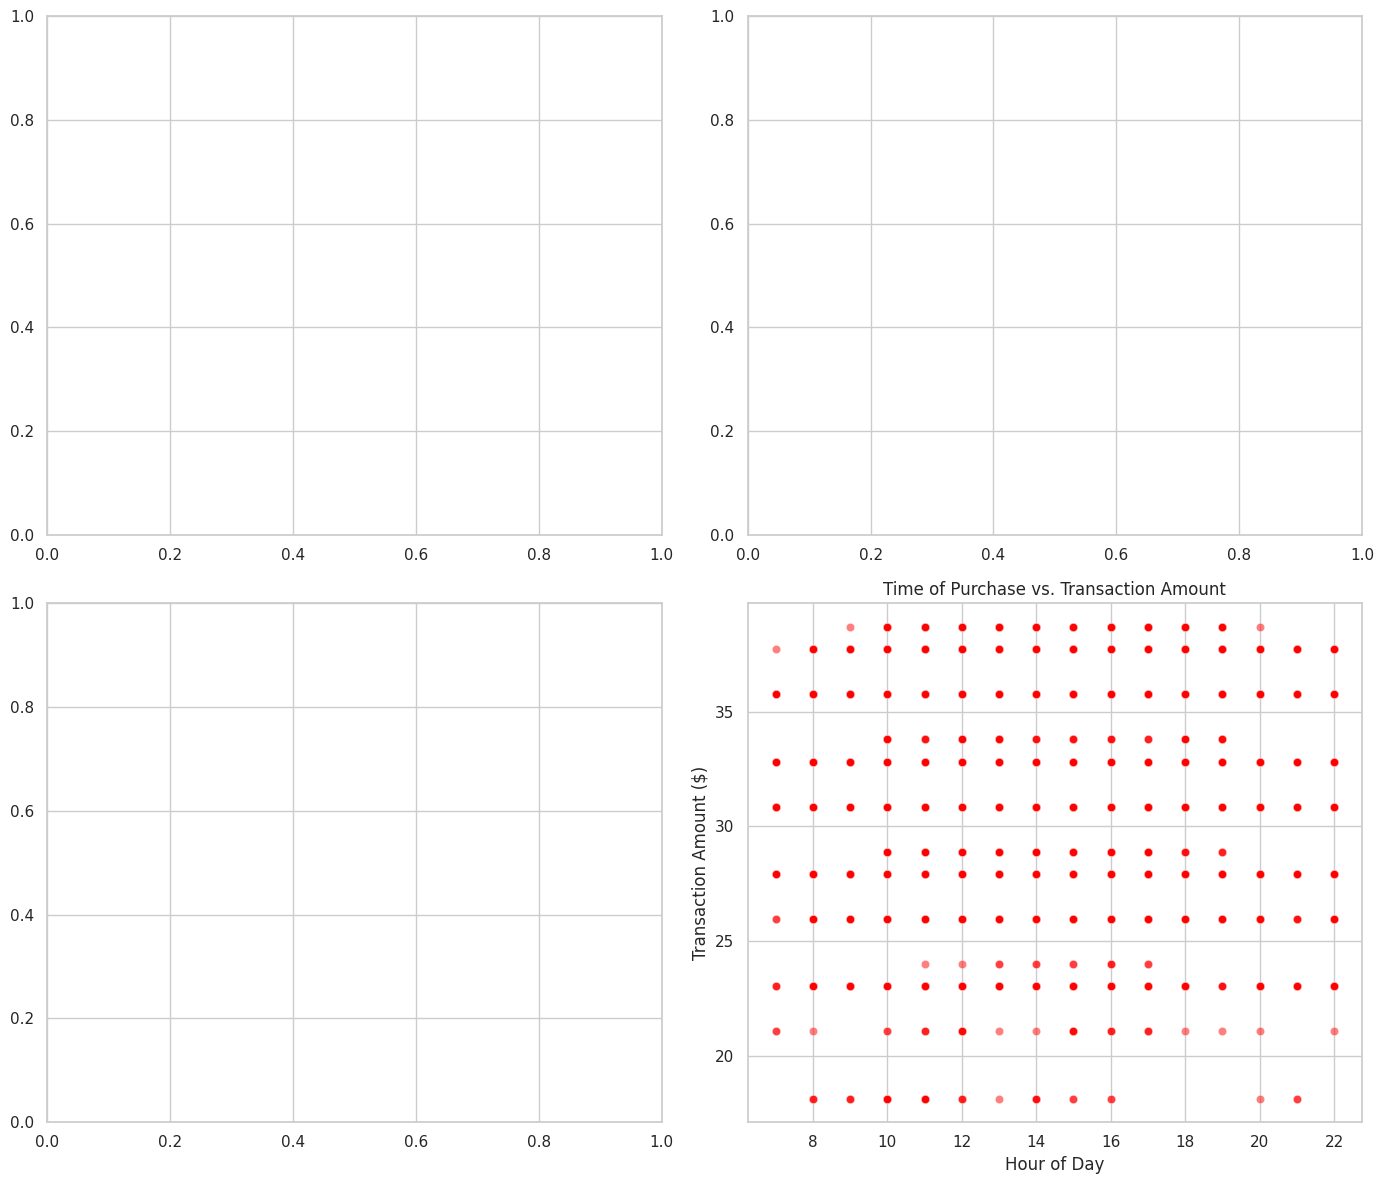

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set plot style
sns.set_theme(style="whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# --- 4. Scatter Plot: Time of Purchase vs. Transaction Amount ---
sns.scatterplot(data=df, x="hour", y="money", alpha=0.5, ax=axes[1, 1], color="red")
axes[1, 1].set_title("Time of Purchase vs. Transaction Amount")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("Transaction Amount ($)")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()